<a href="https://colab.research.google.com/github/0xErdem/Eco-Sentinel/blob/main/wqa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the water quality dataset
# Ensure the CSV file is in the same directory or provide the full path
df = pd.read_csv('water_quality_data.csv')

# Display the first 5 rows to inspect features (e.g., pH, Dissolved Oxygen, Nutrients)
print(df.head())

# Output dataset structure, data types, and non-null counts
print(df.info())


# Step 2: Data Cleaning and Feature Engineering

# 1. Drop administrative, redundant, or mostly empty columns
columns_to_drop = ['Unit_Id', 'Air Temp-Celsius', 'Air Temp (?F)',
                   'DateVerified', 'WhoVerified', 'Field_Tech',
                   'Site_Id', 'Time (24:00)', 'Read_Date', 'Year']
df_cleaned = df.drop(columns=columns_to_drop)

# 2. Fill missing values (NaN) with the median of each respective column
for col in df_cleaned.columns:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# 3. Rename columns for clean, standard Python syntax
df_cleaned.rename(columns={
    'Salinity (ppt)': 'Salinity',
    'Dissolved Oxygen (mg/L)': 'DO',
    'pH (standard units)': 'pH',
    'Secchi Depth (m)': 'Secchi_Depth',
    'Water Depth (m)': 'Water_Depth',
    'Water Temp (?C)': 'Water_Temp',
    'AirTemp (C)': 'Air_Temp'
}, inplace=True)

# Check the cleaned dataset
print(df_cleaned.info())
print("\nMissing values in each column:\n", df_cleaned.isnull().sum())


# Step 3: Feature Engineering - Creating the Target Variable (HAB_Risk)

# Define a function to evaluate environmental conditions for Algal Blooms
def calculate_hab_risk(row):
    risk_score = 0

    # Condition 1: Warm water temperature (> 22 C)
    if row['Water_Temp'] > 22.0:
        risk_score += 1

    # Condition 2: High pH due to intense photosynthesis (> 8.2)
    if row['pH'] > 8.2:
        risk_score += 1

    # Condition 3: High turbidity / Low Secchi Depth (< 0.8 m)
    if row['Secchi_Depth'] < 0.8:
        risk_score += 1

    # Condition 4: Abnormal DO (hypoxia < 4.0 or supersaturation > 10.0 mg/L)
    if row['DO'] < 4.0 or row['DO'] > 10.0:
         risk_score += 1

    # If 2 or more conditions are met, classify as HAB event (1)
    if risk_score >= 2:
        return 1
    else:
        return 0

# Apply the function to create the new target column
df_cleaned['HAB_Risk'] = df_cleaned.apply(calculate_hab_risk, axis=1)

# Check the distribution of the target variable
print("HAB Risk Distribution:")
print(df_cleaned['HAB_Risk'].value_counts())


  Site_Id Unit_Id  Read_Date  Salinity (ppt)  Dissolved Oxygen (mg/L)  \
0     Bay     NaN   1/3/1994             1.3                     11.7   
1     Bay     NaN  1/31/1994             1.5                     12.0   
2     Bay     NaN   2/7/1994             1.0                     10.5   
3     Bay     NaN  2/23/1994             1.0                     10.1   
4     Bay     NaN  2/28/1994             1.0                     12.6   

   pH (standard units)  Secchi Depth (m)  Water Depth (m)  Water Temp (?C)  \
0                  7.3              0.40             0.40              5.9   
1                  7.4              0.20             0.35              3.0   
2                  7.2              0.25             0.60              5.9   
3                  7.4              0.35             0.50             10.0   
4                  7.2              0.20             0.40              1.6   

   Air Temp-Celsius  Air Temp (?F) Time (24:00) Field_Tech DateVerified  \
0               8

AI Detected HAB Events (Anomalies):
HAB_Event
0    2252
1     119
Name: count, dtype: int64


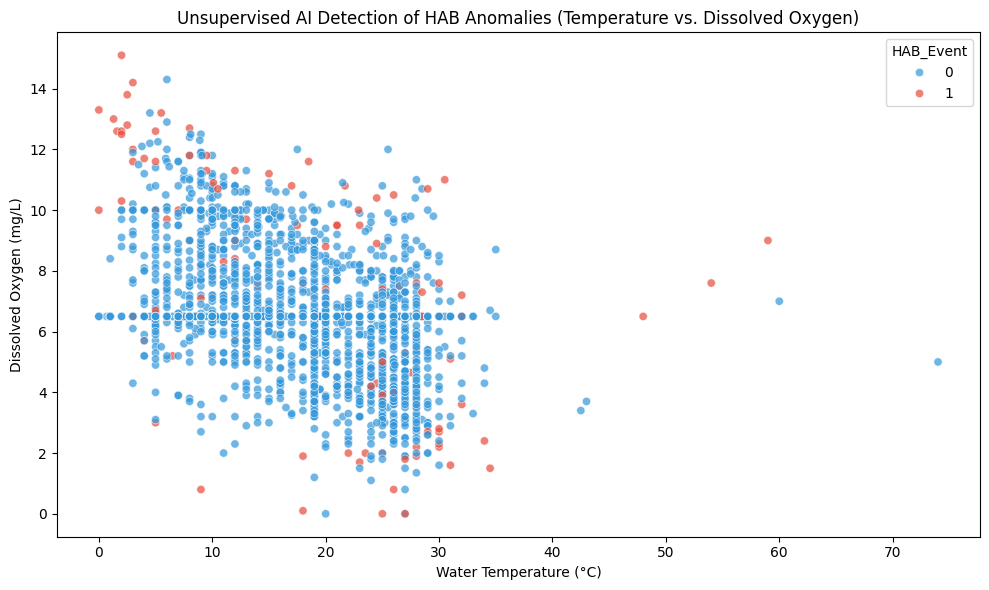

In [ ]:
# Upgraded Step: Unsupervised Anomaly Detection using Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drop the synthetic rules we created earlier (we want the AI to find patterns blindly)
if 'HAB_Risk' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop('HAB_Risk', axis=1)

# 2. Standardize the data (Crucial for advanced ML algorithms so all metrics are on the same scale)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cleaned)

# 3. Initialize the Isolation Forest model
# contamination=0.05 means we assume roughly 5% of the ecosystem's lifetime experiences extreme HAB events
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# 4. Train the model and predict anomalies
# The model returns -1 for anomalies (HAB events) and 1 for normal conditions
df_cleaned['Anomaly'] = iso_forest.fit_predict(scaled_features)

# 5. Map the predictions to a readable format (1 = HAB/Anomaly, 0 = Normal)
df_cleaned['HAB_Event'] = df_cleaned['Anomaly'].apply(lambda x: 1 if x == -1 else 0)

# 6. Check how many anomalies the AI found purely by looking at data variance
print("AI Detected HAB Events (Anomalies):")
print(df_cleaned['HAB_Event'].value_counts())

# 7. Visualize the AI's discovery (Water Temp vs. Dissolved Oxygen)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Water_Temp', y='DO', hue='HAB_Event', data=df_cleaned, palette={0: '#3498db', 1: '#e74c3c'}, alpha=0.7)
plt.title('Unsupervised AI Detection of HAB Anomalies (Temperature vs. Dissolved Oxygen)')
plt.xlabel('Water Temperature (°C)')
plt.ylabel('Dissolved Oxygen (mg/L)')
plt.tight_layout()
plt.show()

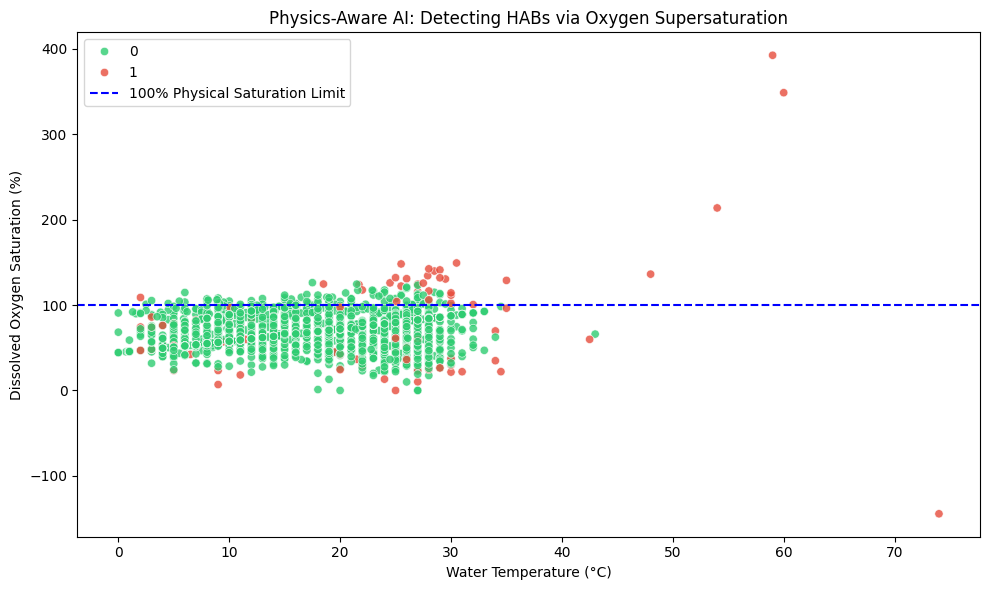

In [ ]:
# 1. Feature Engineering: Injecting Environmental Physics into the Dataset

# Calculate Theoretical DO saturation based on Water Temperature (Empirical Formula)
# Formula approximation for freshwater at 1 atm
df_cleaned['Theoretical_DO'] = (14.652 -
                                (0.41022 * df_cleaned['Water_Temp']) +
                                (0.007991 * (df_cleaned['Water_Temp']**2)) -
                                (0.000077774 * (df_cleaned['Water_Temp']**3)))

# Calculate DO Saturation Percentage
# This tells us if the water has more oxygen than physically possible (Supersaturation due to algae)
df_cleaned['DO_Saturation_Percent'] = (df_cleaned['DO'] / df_cleaned['Theoretical_DO']) * 100

# 2. Re-train Isolation Forest with the new physics-aware feature
# We will drop the raw 'DO' and use our new 'DO_Saturation_Percent' and 'pH' as key indicators
features_for_ai = df_cleaned[['Water_Temp', 'DO_Saturation_Percent', 'pH', 'Secchi_Depth']]

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_ai)

# Initialize model again
iso_forest_advanced = IsolationForest(contamination=0.05, random_state=42)

# Predict true biological anomalies
df_cleaned['Smart_Anomaly'] = iso_forest_advanced.fit_predict(scaled_features)
df_cleaned['Smart_HAB_Event'] = df_cleaned['Smart_Anomaly'].apply(lambda x: 1 if x == -1 else 0)

# 3. Visualize the physically accurate anomalies
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Water_Temp', y='DO_Saturation_Percent', hue='Smart_HAB_Event',
                data=df_cleaned, palette={0: '#2ecc71', 1: '#e74c3c'}, alpha=0.8)

# Draw a line showing the 100% physical saturation limit
plt.axhline(100, color='blue', linestyle='--', label='100% Physical Saturation Limit')

plt.title('Physics-Aware AI: Detecting HABs via Oxygen Supersaturation')
plt.xlabel('Water Temperature (°C)')
plt.ylabel('Dissolved Oxygen Saturation (%)')
plt.legend()
plt.tight_layout()
plt.show()

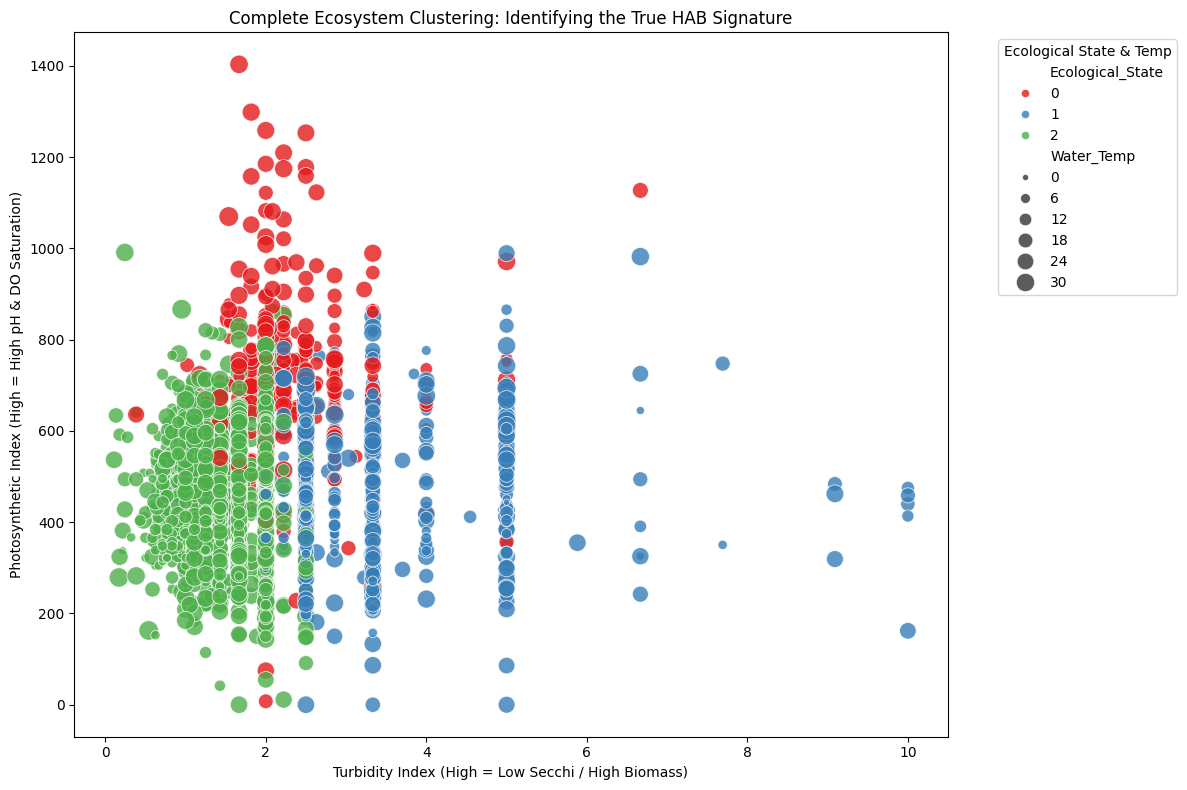

                  Water_Temp  Salinity  Water_Depth  Turbidity_Index  \
Ecological_State                                                       
0                  18.957405  2.761786     0.643417         2.436678   
1                  16.332075  0.298459     0.343884         3.389286   
2                  18.508410  0.192492     0.997431         1.432772   

                  Photosynthetic_Index  
Ecological_State                        
0                           679.746728  
1                           471.832662  
2                           449.397444  


In [ ]:
# 1. Remove obvious sensor errors to clean the AI's vision
df_filtered = df_cleaned[(df_cleaned['Water_Temp'] >= 0) & (df_cleaned['Water_Temp'] <= 40)].copy()
df_filtered = df_filtered[df_filtered['DO_Saturation_Percent'] >= 0]

# 2. Advanced Feature Engineering (Using ALL available data)
# Turbidity Proxy: Lower Secchi depth means higher biomass/turbidity. (Added 0.1 to avoid division by zero)
df_filtered['Turbidity_Index'] = 1 / (df_filtered['Secchi_Depth'] + 0.1)

# Photosynthetic Proxy: Algae blooms cause high pH AND high DO saturation simultaneously
df_filtered['Photosynthetic_Index'] = df_filtered['pH'] * df_filtered['DO_Saturation_Percent']

# Select all engineered and raw features for a complete ecosystem profile
features_for_clustering = ['Water_Temp', 'Salinity', 'Water_Depth', 'Turbidity_Index', 'Photosynthetic_Index']

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Standardize the comprehensive data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_filtered[features_for_clustering])

# 3. K-Means Clustering: Ask AI to find 3 distinct ecological states
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_filtered['Ecological_State'] = kmeans.fit_predict(scaled_features)

# 4. Visualization: 3D-like representation of the ecosystem states
plt.figure(figsize=(12, 8))
# We plot Photosynthetic Index vs Turbidity Index, and size the dots by Temperature
scatter = sns.scatterplot(x='Turbidity_Index', y='Photosynthetic_Index',
                          hue='Ecological_State', palette='Set1',
                          size='Water_Temp', sizes=(20, 200), alpha=0.8,
                          data=df_filtered)

plt.title('Complete Ecosystem Clustering: Identifying the True HAB Signature')
plt.xlabel('Turbidity Index (High = Low Secchi / High Biomass)')
plt.ylabel('Photosynthetic Index (High = High pH & DO Saturation)')
plt.legend(title='Ecological State & Temp', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print the average values of each cluster to understand what the AI found
print(df_filtered.groupby('Ecological_State')[features_for_clustering].mean())